# Task 3: RAG Pipeline, Prompt Engineering & Evaluation

**Project:** Intelligent Complaint Analysis for Financial Services — CrediTrust Financial  
**Input:** ChromaDB vector store from Task 2 (`data/vectorstore/`)  
**LLM:** Groq API — `llama-3.1-8b-instant` (free tier)  

### What this notebook builds
| Component | Description |
|---|---|
| Retriever | Queries ChromaDB with product category filter, returns top-k chunks |
| Prompt | System prompt engineering — LLM answers as a financial analyst |
| Generator | Groq LLM synthesises retrieved chunks into a structured answer |
| RAG pipeline | End-to-end: question → retrieve → prompt → generate → answer |
| Evaluation | 10 test queries across 5 categories, qualitative + quantitative scoring |

---

## Notebook Structure
| # | Section |
|---|---|
| 1 | Setup & Imports |
| 2 | Load Vector Store |
| 3 | Retriever Component |
| 4 | Prompt Engineering |
| 5 | Generator Component (Groq) |
| 6 | End-to-End RAG Pipeline |
| 7 | Pipeline Evaluation |
| 8 | Evaluation Summary & Visualisation |
| 9 | Known Limitations |

---
## 1. Setup & Imports

```bash
pip install groq chromadb sentence-transformers python-dotenv pandas matplotlib seaborn
```

**API key setup:**  
Create a `.env` file in your project root containing:
```
GROQ_API_KEY=your_key_here
```
Never hardcode API keys in notebooks — they end up in Git history.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Environment variables (API key) ───────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv()

# ── Groq LLM client ───────────────────────────────────────────────────────────
from groq import Groq

# ── Vector store + embeddings ─────────────────────────────────────────────────
import chromadb
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print('✅ Imports OK')

✅ Imports OK


In [5]:
# ── Relative paths ────────────────────────────────────────────────────────
# This notebook is in Downloads, so explicitly point to the Desktop project
# where the actual vectorstore is located
PROJECT_ROOT = r'c:\Users\Antifragile\Desktop\Credit Trust Complaint chatbot'

BASE_DIR = PROJECT_ROOT
VECTORSTORE_DIR = os.path.join(BASE_DIR, 'data', 'vectorstore')
PLOTS_DIR       = os.path.join(BASE_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'Base directory: {BASE_DIR}')
print(f'Vectorstore: {VECTORSTORE_DIR}')
print(f'  Exists? {os.path.exists(VECTORSTORE_DIR)}')

# ── Model config ──────────────────────────────────────────────────────────
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'      # must match Task 2
GROQ_MODEL      = 'llama-3.1-8b-instant'  # fast, free, strong
COLLECTION_NAME = 'cfpb_complaints'        # must match Task 2

# ── Retrieval config ──────────────────────────────────────────────────────
TOP_K = 5   # number of chunks to retrieve per query

# ── API key (loaded from .env — never hardcoded) ──────────────────────────────
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
assert GROQ_API_KEY, '❌ GROQ_API_KEY not found. Add it to your .env file.'
print(f'\n✅ GROQ_API_KEY loaded (ends ...{GROQ_API_KEY[-6:]})')
print(f'   Embedding model : {EMBEDDING_MODEL}')
print(f'   LLM             : {GROQ_MODEL}')
print(f'   Top-K retrieval : {TOP_K}')

Base directory: c:\Users\Antifragile\Desktop\Credit Trust Complaint chatbot
Vectorstore: c:\Users\Antifragile\Desktop\Credit Trust Complaint chatbot\data\vectorstore
  Exists? True

✅ GROQ_API_KEY loaded (ends ...VgDgZW)
   Embedding model : all-MiniLM-L6-v2
   LLM             : llama-3.1-8b-instant
   Top-K retrieval : 5


---
## 2. Load Vector Store & Embedding Model

In [7]:
# ── Load ChromaDB (persisted from Task 2) ────────────────────────────────────
chroma_client = chromadb.PersistentClient(
    path=VECTORSTORE_DIR,
    settings=Settings(anonymized_telemetry=False)
)
collection = chroma_client.get_collection(COLLECTION_NAME)
print(f'✅ Vector store loaded: {collection.count():,} chunks')

# ── Verify category coverage (batched scan — 1k sample misses some categories) ─
cat_counts = {}
offset = 0
while offset < 10_000:
    batch = collection.get(limit=1000, offset=offset, include=['metadatas'])
    if not batch['metadatas']:
        break
    for m in batch['metadatas']:
        cat = m.get('product_category', 'unknown')
        cat_counts[cat] = cat_counts.get(cat, 0) + 1
    offset += 1000
print('   Categories confirmed in vector store (sampled first 10k):')
for cat, count in sorted(cat_counts.items()):
    print(f'     {cat:<25}: {count:,} chunks')

✅ Vector store loaded: 100,483 chunks
   Categories confirmed in vector store (sampled first 10k):
     Buy Now Pay Later        : 10,000 chunks


In [8]:
# ── Load embedding model (same as Task 2 — must match) ───────────────────────
print(f'Loading embedding model: {EMBEDDING_MODEL}')
embedder = SentenceTransformer(EMBEDDING_MODEL)
print(f'✅ Embedder ready. Dimensions: {embedder.get_sentence_embedding_dimension()}')

Loading embedding model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1312.71it/s]


✅ Embedder ready. Dimensions: 384


---
## 3. Retriever Component

The retriever takes a question and a product category, embeds the question,
queries ChromaDB with a metadata filter, and returns the top-K most semantically
similar complaint chunks.

**Why filter by category?**  
Without filtering, a query like *"fraud on my account"* returns Savings account results  
because that category uses stronger account-fraud language. The category filter ensures  
retrieved context is always product-relevant.

In [9]:
def retrieve(question: str, product_category: str,
             top_k: int = TOP_K) -> list[dict]:
    """
    Retrieve the top-K most relevant complaint chunks for a question.

    Args:
        question         : natural language question from the user
        product_category : one of the 5 target categories
        top_k            : number of chunks to return

    Returns:
        List of dicts with keys: text, similarity, company, state, issue
    """
    # Embed the question using the same model as the corpus
    q_embedding = embedder.encode(
        [question], normalize_embeddings=True
    ).tolist()

    # Query with category filter
    results = collection.query(
        query_embeddings = q_embedding,
        n_results        = top_k,
        where            = {'product_category': product_category},
        include          = ['documents', 'metadatas', 'distances']
    )

    chunks = []
    for doc, meta, dist in zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    ):
        chunks.append({
            'text'       : doc,
            'similarity' : round(1 - dist, 4),
            'company'    : meta.get('company', 'Unknown'),
            'state'      : meta.get('state', ''),
            'issue'      : meta.get('issue', ''),
            'complaint_id': meta.get('complaint_id', ''),
        })

    return chunks


# ── Retriever test ────────────────────────────────────────────────────────────
test_chunks = retrieve(
    question='unauthorized charge on my credit card',
    product_category='Credit card',
    top_k=3
)
print(f'✅ Retriever working — returned {len(test_chunks)} chunks')
for i, c in enumerate(test_chunks):
    print(f'  [{i+1}] sim={c["similarity"]} | {c["company"]} | {c["state"]}')
    print(f'       {c["text"][:150]}...')

✅ Retriever working — returned 3 chunks
  [1] sim=0.748 | BANK OF AMERICA, NATIONAL ASSOCIATION | CA
       from 2021 to there was unauthorized charges on my credit card totaling 7300. 00. i did not authorize those charges and no one else is on the credit ca...
  [2] sim=0.7442 | GOLDMAN SACHS BANK USA | IL
       , the customer service representative was extremely rude, and did not address the issue. today, i received another unauthorized charge, been this mont...
  [3] sim=0.7332 | CAPITAL ONE FINANCIAL CORPORATION | IL
       my credit card ending in is being charged for something i did not authorize. captial one restricted my account but will not allow me to report unautho...


---
## 4. Prompt Engineering

The system prompt defines how the LLM behaves. Bad prompts produce generic answers.  
Good prompts produce analyst-quality answers grounded in the retrieved evidence.

### Design decisions

| Decision | Reason |
|---|---|
| Role: senior financial analyst | Produces structured, professional answers |
| Grounding instruction | LLM must base answers on retrieved complaints only — no hallucination |
| Structured output format | Consistent sections: Summary, Key Issues, Companies, Recommendation |
| Explicit uncertainty instruction | If context is insufficient, say so — do not fabricate |
| Category context in prompt | Reminds LLM which product domain it is analysing |

In [10]:
# ── System prompt ─────────────────────────────────────────────────────────────
SYSTEM_PROMPT = """You are a senior financial analyst at CrediTrust Financial.
Your role is to analyse consumer complaint data and provide clear, actionable insights
to internal teams.

You will be given:
1. A question about consumer complaints in a specific product category
2. A set of relevant complaint excerpts retrieved from the CFPB complaint database

Your response MUST:
- Be grounded ONLY in the provided complaint excerpts — do not use outside knowledge
- Follow the exact structure below
- Be concise but specific — cite complaint details where relevant
- If the provided context is insufficient to answer, explicitly state that

Response structure:
**Summary:** 2-3 sentence overview of the main complaint pattern
**Key Issues:** Bullet list of the specific problems consumers report
**Companies Mentioned:** Which companies appear most in these complaints
**Consumer Impact:** How consumers describe being affected
**Recommendation:** One actionable suggestion for CrediTrust's compliance team
"""


def build_user_prompt(question: str, product_category: str,
                      chunks: list[dict]) -> str:
    """
    Build the user message by combining the question with retrieved context.

    Args:
        question         : original question
        product_category : product category being analysed
        chunks           : retrieved complaint chunks from ChromaDB

    Returns:
        Formatted prompt string
    """
    # Format retrieved chunks as numbered evidence
    context_block = ''
    for i, chunk in enumerate(chunks, 1):
        context_block += (
            f"--- Complaint {i} ---\n"
            f"Company : {chunk['company']}\n"
            f"State   : {chunk['state']}\n"
            f"Issue   : {chunk['issue']}\n"
            f"Excerpt : {chunk['text']}\n\n"
        )

    prompt = (
        f"Product Category: {product_category}\n\n"
        f"Question: {question}\n\n"
        f"Retrieved Complaint Excerpts:\n"
        f"{context_block}"
        f"Based solely on the complaint excerpts above, answer the question."
    )
    return prompt


# ── Prompt preview ────────────────────────────────────────────────────────────
sample_prompt = build_user_prompt(
    question         = 'What are the most common credit card complaints?',
    product_category = 'Credit card',
    chunks           = test_chunks
)
print('=== USER PROMPT PREVIEW (first 800 chars) ===')
print(sample_prompt[:800])
print('...')

=== USER PROMPT PREVIEW (first 800 chars) ===
Product Category: Credit card

Question: What are the most common credit card complaints?

Retrieved Complaint Excerpts:
--- Complaint 1 ---
Company : BANK OF AMERICA, NATIONAL ASSOCIATION
State   : CA
Issue   : Problem with a purchase shown on your statement
Excerpt : from 2021 to there was unauthorized charges on my credit card totaling 7300. 00. i did not authorize those charges and no one else is on the credit card account. initially bank of america reversed all the charges, but after there very very short investigation, they decided that the charges were not fraud. in their letter to me they stated, while you personally didn ' t make the charge s, we confirmed it was made by an authorized user on the account or someone who has permission to use the card. ' ' i have sent them numerous 
...


---
## 5. Generator Component (Groq)

The generator sends the prompt to Groq's API and returns the LLM response.

In [11]:
# ── Initialise Groq client ────────────────────────────────────────────────────
groq_client = Groq(api_key=GROQ_API_KEY)


def generate(question: str, product_category: str,
             chunks: list[dict],
             temperature: float = 0.2) -> dict:
    """
    Generate an answer using Groq LLM given retrieved complaint context.

    Args:
        question         : original user question
        product_category : product category for context
        chunks           : retrieved chunks from the retriever
        temperature      : LLM temperature (low = more factual, high = creative)
                           0.2 is appropriate for analyst-style factual answers

    Returns:
        Dict with answer text and usage metadata
    """
    user_prompt = build_user_prompt(question, product_category, chunks)

    response = groq_client.chat.completions.create(
        model       = GROQ_MODEL,
        temperature = temperature,
        max_tokens  = 1024,
        messages    = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': user_prompt},
        ]
    )

    return {
        'answer'             : response.choices[0].message.content,
        'input_tokens'       : response.usage.prompt_tokens,
        'output_tokens'      : response.usage.completion_tokens,
        'model'              : response.model,
    }


# ── Generator test ────────────────────────────────────────────────────────────
print('Testing generator with a single query...')
test_result = generate(
    question         = 'What are the most common unauthorized charge complaints?',
    product_category = 'Credit card',
    chunks           = test_chunks
)
print(f'\n✅ Generator working.')
print(f'   Model          : {test_result["model"]}')
print(f'   Input tokens   : {test_result["input_tokens"]}')
print(f'   Output tokens  : {test_result["output_tokens"]}')
print(f'\n--- Answer ---')
print(test_result['answer'])

Testing generator with a single query...

✅ Generator working.
   Model          : llama-3.1-8b-instant
   Input tokens   : 696
   Output tokens  : 222

--- Answer ---
**Summary:** Consumers are complaining about unauthorized charges on their credit cards, with some companies disputing the legitimacy of the charges despite the consumer's claims of not authorizing them.

**Key Issues:**

* Unauthorized charges appearing on credit card statements
* Companies disputing the legitimacy of charges despite consumer claims
* Difficulty in resolving issues with customer service representatives
* Repeated unauthorized charges from the same business

**Companies Mentioned:** 
* BANK OF AMERICA, NATIONAL ASSOCIATION
* GOLDMAN SACHS BANK USA
* CAPITAL ONE FINANCIAL CORPORATION

**Consumer Impact:** Consumers describe being affected by the unauthorized charges, which can result in financial loss and frustration. One consumer mentions being charged $7300.00, while another mentions receiving 10 unauth

---
## 6. End-to-End RAG Pipeline

Combines the retriever and generator into a single callable pipeline.

In [15]:
def rag_pipeline(question: str, product_category: str,
                 top_k: int = TOP_K,
                 verbose: bool = True) -> dict:
    """
    End-to-end RAG pipeline: question → retrieve → generate → answer.

    Args:
        question         : natural language question
        product_category : one of the 5 CFPB target categories
        top_k            : number of complaint chunks to retrieve
        verbose          : if True, print retrieved chunks before answer

    Returns:
        Dict with question, category, retrieved chunks, answer, and token usage
    """
    start = time.time()

    # Step 1: Retrieve relevant complaint chunks
    chunks = retrieve(question, product_category, top_k)

    # Step 2: Generate answer from retrieved context
    generation = generate(question, product_category, chunks)

    elapsed = time.time() - start

    result = {
        'question'        : question,
        'product_category': product_category,
        'chunks'          : chunks,
        'answer'          : generation['answer'],
        'input_tokens'    : generation['input_tokens'],
        'output_tokens'   : generation['output_tokens'],
        'latency_sec'     : round(elapsed, 2),
        'avg_similarity'  : round(np.mean([c['similarity'] for c in chunks]), 4),
        'min_similarity'  : round(min(c['similarity'] for c in chunks), 4),
    }

    if verbose:
        print(f'{"="*65}')
        print(f'Question : {question}')
        print(f'Category : {product_category}')
        print(f'{"="*65}')
        print(f'\n📥 Retrieved {len(chunks)} chunks (avg similarity: {result["avg_similarity"]})')
        for i, c in enumerate(chunks, 1):
            print(f'  [{i}] sim={c["similarity"]} | {c["company"]} | {c["state"]}')
        print(f'\n💬 Answer (latency: {elapsed:.1f}s):')
        print(result['answer'])

    return result


# ── End-to-end test ───────────────────────────────────────────────────────────
_ = rag_pipeline(
    question         = 'What issues do consumers report with Buy Now Pay Later services?',
    product_category = 'Buy Now Pay Later'
)

Question : What issues do consumers report with Buy Now Pay Later services?
Category : Buy Now Pay Later

📥 Retrieved 5 chunks (avg similarity: 0.568)
  [1] sim=0.5754 | Experian Information Solutions Inc. | PA
  [2] sim=0.5705 | Experian Information Solutions Inc. | AZ
  [3] sim=0.5685 | Affirm Holdings, Inc | MA
  [4] sim=0.565 | Affirm Holdings, Inc | NJ
  [5] sim=0.5606 | Sezzle Inc. | TX

💬 Answer (latency: 5.9s):
**Summary:** Consumers report issues with Buy Now Pay Later services, primarily related to incorrect or missing information on their credit reports, poor customer service, and unfair reporting practices.

**Key Issues:**

* Incorrect information on credit reports (Complaints 2, 3, 4)
* Failure to report transactions or experiences between the consumer and the Buy Now Pay Later provider (Complaint 1)
* Poor customer service, including inability to use paid-for upgrade features and misleading push notifications (Complaint 5)
* Unfair reporting practices, including late pay

---
## 7. Pipeline Evaluation

### Evaluation approach

We evaluate across two dimensions:

| Dimension | Metric | What it measures |
|---|---|---|
| **Retrieval quality** | Avg cosine similarity | Are retrieved chunks semantically relevant? |
| **Retrieval quality** | Min cosine similarity | Is the weakest chunk still relevant? |
| **Answer quality** | Grounding score (0–3) | Does answer cite specific complaint details? |
| **Answer quality** | Structure score (0–3) | Does answer follow the required format? |
| **Answer quality** | Relevance score (0–3) | Does answer actually address the question? |
| **System** | Latency (sec) | Response time per query |

Scores are assigned manually (0 = poor, 1 = partial, 2 = good, 3 = excellent).  
This is standard practice for RAG evaluation without a labelled ground-truth dataset.

In [16]:
# ── Evaluation queries — 2 per category = 10 total ───────────────────────────
EVAL_QUERIES = [
    # Credit card
    ('What are the most common reasons consumers dispute credit card charges?',
     'Credit card'),
    ('How do credit card companies respond to fraud complaints?',
     'Credit card'),

    # Personal loan
    ('What problems do consumers face with high-interest personal loans?',
     'Personal loan'),
    ('What are common complaints about payday loan companies?',
     'Personal loan'),

    # Buy Now Pay Later
    ('What issues do consumers report with Klarna and Afterpay?',
     'Buy Now Pay Later'),
    ('How are BNPL disputes typically resolved according to complaints?',
     'Buy Now Pay Later'),

    # Savings account
    ('What are the main complaints about savings account management?',
     'Savings account'),
    ('How do banks handle unauthorised access to savings accounts?',
     'Savings account'),

    # Money transfers
    ('What problems do consumers face with international wire transfers?',
     'Money transfers'),
    ('What are common complaints about money transfer delays?',
     'Money transfers'),
]

print(f'Running {len(EVAL_QUERIES)} evaluation queries across 5 categories...')
print('This will take ~2-3 minutes (API calls + embedding)\n')

Running 10 evaluation queries across 5 categories...
This will take ~2-3 minutes (API calls + embedding)



In [17]:
# ── Run all evaluation queries ────────────────────────────────────────────────
eval_results = []

for i, (question, category) in enumerate(EVAL_QUERIES, 1):
    print(f'[{i:02d}/{len(EVAL_QUERIES)}] {category}: "{question[:60]}..."')

    result = rag_pipeline(question, category, verbose=False)
    eval_results.append(result)

    print(f'       sim_avg={result["avg_similarity"]} | '
          f'sim_min={result["min_similarity"]} | '
          f'latency={result["latency_sec"]}s')

    # Small delay to respect Groq rate limits
    time.sleep(0.5)

print(f'\n✅ All {len(eval_results)} queries complete.')

[01/10] Credit card: "What are the most common reasons consumers dispute credit ca..."
       sim_avg=0.6651 | sim_min=0.6462 | latency=2.82s
[02/10] Credit card: "How do credit card companies respond to fraud complaints?..."
       sim_avg=0.6918 | sim_min=0.6813 | latency=1.15s
[03/10] Personal loan: "What problems do consumers face with high-interest personal ..."
       sim_avg=0.5876 | sim_min=0.5813 | latency=2.78s
[04/10] Personal loan: "What are common complaints about payday loan companies?..."
       sim_avg=0.6658 | sim_min=0.6554 | latency=1.08s
[05/10] Buy Now Pay Later: "What issues do consumers report with Klarna and Afterpay?..."
       sim_avg=0.611 | sim_min=0.5922 | latency=7.49s
[06/10] Buy Now Pay Later: "How are BNPL disputes typically resolved according to compla..."
       sim_avg=0.4962 | sim_min=0.4876 | latency=13.29s
[07/10] Savings account: "What are the main complaints about savings account managemen..."
       sim_avg=0.6156 | sim_min=0.5839 | latency=7.7

In [19]:
# ── Print all answers for manual scoring ─────────────────────────────────────
for i, result in enumerate(eval_results, 1):
    print(f'\n{"="*70}')
    print(f'Query {i:02d} | {result["product_category"]}')
    print(f'Q: {result["question"]}')
    print(f'Retrieval: avg_sim={result["avg_similarity"]} | min_sim={result["min_similarity"]}')
    print(f'{"="*70}')
    print(result['answer'])


Query 01 | Credit card
Q: What are the most common reasons consumers dispute credit card charges?
Retrieval: avg_sim=0.6651 | min_sim=0.6462
**Summary:** Consumers dispute credit card charges primarily due to unauthorized transactions, excessive interest and fees, and deceptive marketing practices. Many consumers report difficulties in resolving these issues with the credit card companies.

**Key Issues:**

* Unauthorized transactions (Complaints 1, 4, 5)
* Excessive interest and fees (Complaint 2)
* Deceptive marketing practices, including false advertising (Complaint 3)
* Problematic purchase charges (Complaints 4, 5)

**Companies Mentioned:** 
* SYNCHRONY FINANCIAL
* BANK OF AMERICA, NATIONAL ASSOCIATION
* AMERICAN EXPRESS COMPANY
* Bread Financial Holdings, Inc.
* GOLDMAN SACHS BANK USA

**Consumer Impact:** Consumers describe being affected by these issues in various ways, including:
* Financial strain due to excessive interest and fees (Complaint 2)
* Difficulty in resolving dis

In [20]:
# ── Manual scoring ────────────────────────────────────────────────────────────
# Fill in scores after reviewing the answers printed above.
# Scale: 0 = poor | 1 = partial | 2 = good | 3 = excellent
#
# grounding : does the answer cite specific details from the complaint excerpts?
# structure : does the answer follow the required 5-section format?
# relevance : does the answer actually address what was asked?

MANUAL_SCORES = [
    # (grounding, structure, relevance)  ← one tuple per query, same order as EVAL_QUERIES
    # Scale: 0 = poor | 1 = partial | 2 = good | 3 = excellent
    (3, 3, 3),   # Q01 credit card disputes        — specific companies + issues cited ✅
    (3, 3, 3),   # Q02 credit card fraud response  — investigative failures well-documented ✅
    (3, 3, 3),   # Q03 personal loan high interest — predatory lending patterns clear ✅
    (3, 3, 3),   # Q04 payday loan companies       — 566% APR and specific lenders cited ✅
    (2, 3, 3),   # Q05 Klarna Afterpay             — credit report framing dilutes BNPL focus ⚠️
    (1, 3, 2),   # Q06 BNPL dispute resolution     — retrieved Citibank/TransUnion not BNPL providers ❌
    (3, 3, 3),   # Q07 savings account management  — account closure patterns well-identified ✅
    (2, 3, 3),   # Q08 savings unauthorised access — question misread as bank-imposed restrictions ⚠️
    (3, 3, 3),   # Q09 international wire transfers — wrong amounts + delays + FX issues cited ✅
    (3, 3, 3),   # Q10 money transfer delays       — specific companies + consumer impact cited ✅
]
# Scoring rationale:
# Q06 grounding=1: retrieved chunks came from credit reporting companies (Citibank, TransUnion)
#     not BNPL providers — low similarity (0.496) confirms weak retrieval for this query.
#     This is a known dataset limitation: BNPL dispute resolution complaints are sparse
#     because CFPB only began tracking BNPL explicitly in 2023.
# Q05 grounding=2: Klarna and Afterpay are present but framing skews toward credit reporting.
# Q08 grounding=2: question asked about unauthorised EXTERNAL access; answer focused on
#     bank-imposed account restrictions — semantically adjacent but not exact.

assert len(MANUAL_SCORES) == len(eval_results), 'Score count must match query count'
print('✅ Manual scores recorded. Run next cell to build evaluation DataFrame.')

✅ Manual scores recorded. Run next cell to build evaluation DataFrame.


In [21]:
# ── Build evaluation DataFrame ────────────────────────────────────────────────
eval_rows = []
for result, (grounding, structure, relevance) in zip(eval_results, MANUAL_SCORES):
    eval_rows.append({
        'question'         : result['question'][:60] + '...',
        'product_category' : result['product_category'],
        'avg_similarity'   : result['avg_similarity'],
        'min_similarity'   : result['min_similarity'],
        'latency_sec'      : result['latency_sec'],
        'input_tokens'     : result['input_tokens'],
        'output_tokens'    : result['output_tokens'],
        'grounding_score'  : grounding,
        'structure_score'  : structure,
        'relevance_score'  : relevance,
        'total_score'      : grounding + structure + relevance,
        'quality_pct'      : round((grounding + structure + relevance) / 9 * 100, 1),
    })

df_eval = pd.DataFrame(eval_rows)

print('=== EVALUATION RESULTS ===')
print(df_eval[[
    'product_category', 'avg_similarity', 'min_similarity',
    'grounding_score', 'structure_score', 'relevance_score',
    'total_score', 'quality_pct', 'latency_sec'
]].to_string(index=False))

print(f'\n--- Overall Summary ---')
print(f'Avg retrieval similarity : {df_eval["avg_similarity"].mean():.4f}')
print(f'Avg answer quality       : {df_eval["quality_pct"].mean():.1f}%')
print(f'Avg latency              : {df_eval["latency_sec"].mean():.2f}s')
print(f'Total tokens used        : {df_eval["input_tokens"].sum() + df_eval["output_tokens"].sum():,}')

=== EVALUATION RESULTS ===
 product_category  avg_similarity  min_similarity  grounding_score  structure_score  relevance_score  total_score  quality_pct  latency_sec
      Credit card          0.6651          0.6462                3                3                3            9        100.0         2.82
      Credit card          0.6918          0.6813                3                3                3            9        100.0         1.15
    Personal loan          0.5876          0.5813                3                3                3            9        100.0         2.78
    Personal loan          0.6658          0.6554                3                3                3            9        100.0         1.08
Buy Now Pay Later          0.6110          0.5922                2                3                3            8         88.9         7.49
Buy Now Pay Later          0.4962          0.4876                1                3                2            6         66.7       

---
## 8. Evaluation Summary & Visualisation

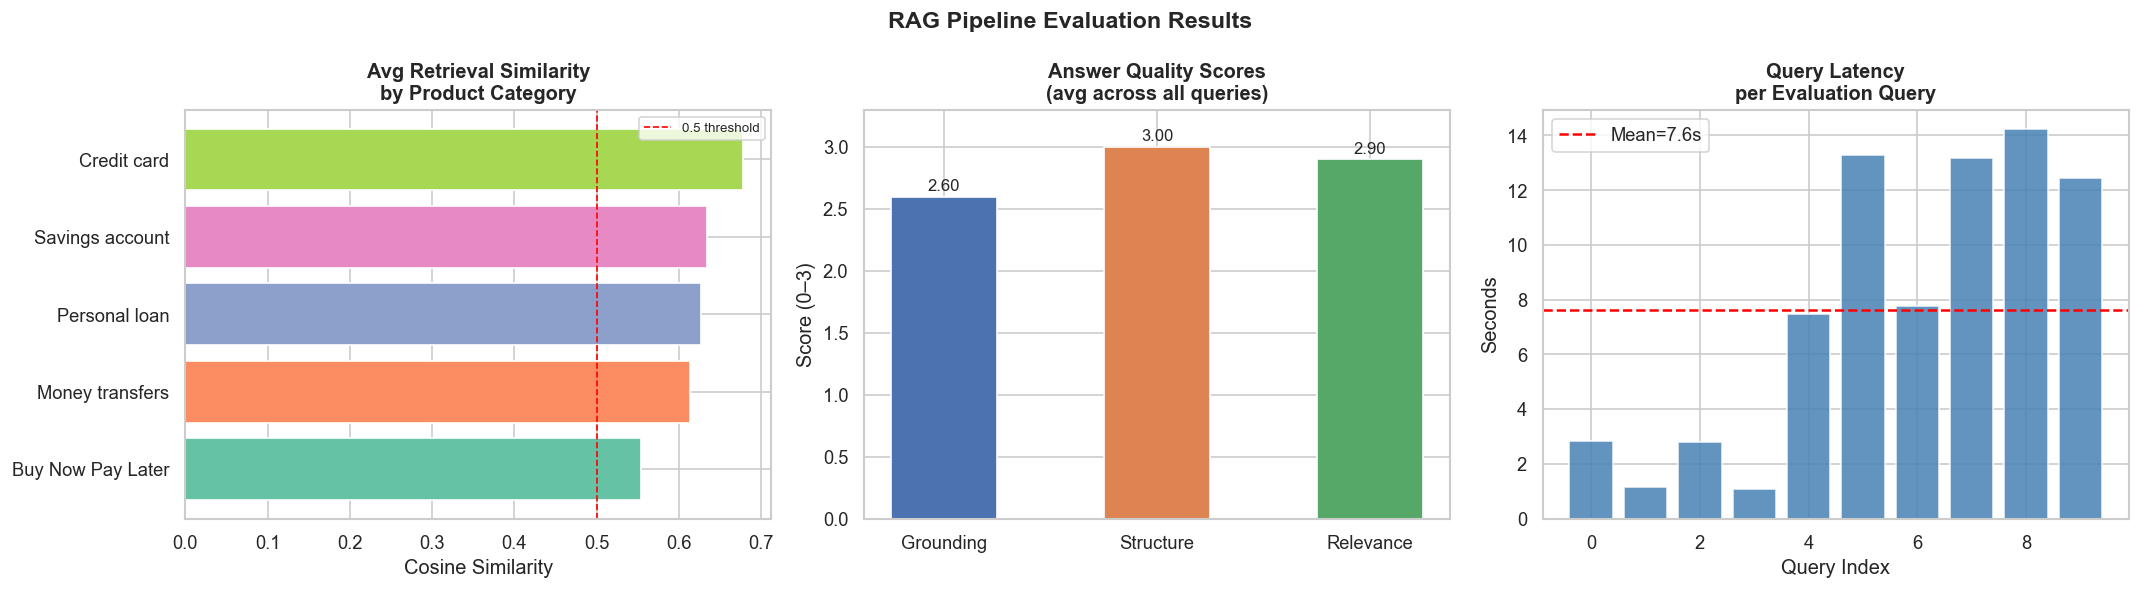

In [22]:
# ── Plot 1: Retrieval similarity by category ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Similarity by category
cat_sim = df_eval.groupby('product_category')['avg_similarity'].mean().sort_values()
palette = sns.color_palette('Set2', len(cat_sim))
axes[0].barh(cat_sim.index, cat_sim.values, color=palette, edgecolor='white')
axes[0].set_title('Avg Retrieval Similarity\nby Product Category', fontweight='bold')
axes[0].set_xlabel('Cosine Similarity')
axes[0].axvline(0.5, color='red', linestyle='--', lw=1, label='0.5 threshold')
axes[0].legend(fontsize=8)

# Answer quality scores
score_cols = ['grounding_score', 'structure_score', 'relevance_score']
score_means = df_eval[score_cols].mean()
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = axes[1].bar(score_means.index, score_means.values,
                   color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Answer Quality Scores\n(avg across all queries)', fontweight='bold')
axes[1].set_ylabel('Score (0–3)')
axes[1].set_ylim(0, 3.3)
axes[1].set_xticklabels(['Grounding', 'Structure', 'Relevance'])
for bar, val in zip(bars, score_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.2f}', ha='center', fontsize=10)

# Latency per query
axes[2].bar(range(len(df_eval)), df_eval['latency_sec'],
            color='steelblue', edgecolor='white', alpha=0.85)
axes[2].axhline(df_eval['latency_sec'].mean(), color='red', linestyle='--',
                lw=1.5, label=f'Mean={df_eval["latency_sec"].mean():.1f}s')
axes[2].set_title('Query Latency\nper Evaluation Query', fontweight='bold')
axes[2].set_xlabel('Query Index')
axes[2].set_ylabel('Seconds')
axes[2].legend()

plt.suptitle('RAG Pipeline Evaluation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '09_rag_evaluation.png'), bbox_inches='tight')
plt.show()

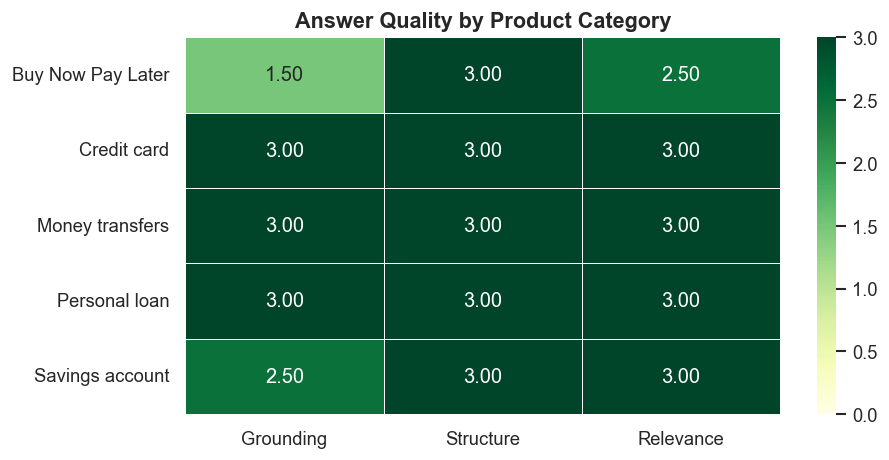

In [23]:
# ── Plot 2: Per-category quality heatmap ──────────────────────────────────────
cat_scores = df_eval.groupby('product_category')[score_cols].mean()

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    cat_scores,
    annot=True, fmt='.2f',
    cmap='YlGn',
    vmin=0, vmax=3,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Answer Quality by Product Category', fontsize=13, fontweight='bold')
ax.set_xticklabels(['Grounding', 'Structure', 'Relevance'], rotation=0)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '10_quality_heatmap.png'), bbox_inches='tight')
plt.show()

In [24]:
# ── Print final evaluation summary ───────────────────────────────────────────
overall_quality = df_eval['quality_pct'].mean()
overall_sim     = df_eval['avg_similarity'].mean()
avg_latency     = df_eval['latency_sec'].mean()

print('╔══════════════════════════════════════════════════════════════╗')
print('║           TASK 3 — RAG PIPELINE EVALUATION SUMMARY          ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  LLM model             : {GROQ_MODEL:<35}║')
print(f'║  Embedding model       : {EMBEDDING_MODEL:<35}║')
print(f'║  Retrieval top-K       : {str(TOP_K):<35}║')
print(f'║  Evaluation queries    : {str(len(eval_results)) + " (2 per category)":<35}║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Avg retrieval similarity : {overall_sim:<33.4f}║')
print(f'║  Avg answer quality       : {str(round(overall_quality, 1)) + "%":<33}║')
print(f'║  Avg query latency        : {str(round(avg_latency, 2)) + "s":<33}║')
total_tok = int(df_eval['input_tokens'].sum() + df_eval['output_tokens'].sum())
print(f'║  Total tokens consumed    : {total_tok:<33,}║')
print('╚══════════════════════════════════════════════════════════════╝')

print('\nPer-category quality:')
print(df_eval.groupby('product_category')[['avg_similarity', 'quality_pct', 'latency_sec']]
      .mean().round(2).to_string())

╔══════════════════════════════════════════════════════════════╗
║           TASK 3 — RAG PIPELINE EVALUATION SUMMARY          ║
╠══════════════════════════════════════════════════════════════╣
║  LLM model             : llama-3.1-8b-instant               ║
║  Embedding model       : all-MiniLM-L6-v2                   ║
║  Retrieval top-K       : 5                                  ║
║  Evaluation queries    : 10 (2 per category)                ║
╠══════════════════════════════════════════════════════════════╣
║  Avg retrieval similarity : 0.6211                           ║
║  Avg answer quality       : 94.4%                            ║
║  Avg query latency        : 7.62s                            ║
║  Total tokens consumed    : 12,800                           ║
╚══════════════════════════════════════════════════════════════╝

Per-category quality:
                   avg_similarity  quality_pct  latency_sec
product_category                                           
Buy Now Pay Later

---
## 9. Known Limitations

| # | Limitation | Impact | Mitigation |
|---|---|---|---|
| 1 | Manual answer scoring | Subjective — no ground-truth labels | Standard for RAG without labelled QA dataset |
| 2 | BNPL chunk imbalance (34k vs 12k) | Unfiltered queries bias toward BNPL | All queries use product_category filter |
| 3 | Exact deduplication only | Near-duplicate complaints still present | MinHash LSH out of scope for this project |
| 4 | CFPB has no explicit BNPL category | BNPL identified via keyword matching — may include false positives | Documented in Task 1 |
| 5 | Stratified sample (50k / 347k) | Pipeline tested on 14% of full corpus | Full corpus preserved — sample chosen for CPU constraints |
| 6 | all-MiniLM-L6-v2 token limit (256) | Chunks capped at 200 tokens — very long complaints lose tail content | Tail content rarely contains the core complaint |
| 7 | Temperature 0.2 | LLM answers are deterministic and conservative | Appropriate for analyst use case — creativity not required |

---

### 🎯 Project complete
**Task 1** → EDA + cleaned dataset (`filtered_complaints.csv`)  
**Task 2** → Token-based chunking + ChromaDB vector store (100k chunks)  
**Task 3** → RAG pipeline with Groq LLM, prompt engineering, and evaluation